In [ ]:
import pandas as pd
import numpy as np

# Load your dataset
dataset = pd.read_csv('/content/software_quality_dataset.csv')


print(dataset.head(6))

# shape of dataset
print(f"Dataset shape: {dataset.shape}")


   Lines_of_Code  Cyclomatic_Complexity  Num_Functions  Code_Churn  \
0          356.0                     31            144   69.567047   
1          227.0                     15            104  131.844422   
2         9674.0                     47            141  118.729027   
3         6967.0                     42            107  194.397155   
4         7954.0                     35            114   69.202293   
5         2305.0                     38            120  164.299559   

   Comment_Density  Num_Bugs Has_Unit_Tests  Code_Owner_Experience  \
0         0.467561         2            Yes                      4   
1         0.795643         2             No                      5   
2         0.316839         5             No                      1   
3         0.971883         5            Yes                      3   
4         0.559417         1             No                      8   
5         0.353860         5             No                      6   

  Quality_Label  


In [ ]:
# missing values
print(dataset.isnull().sum())


Lines_of_Code            80
Cyclomatic_Complexity     0
Num_Functions             0
Code_Churn               80
Comment_Density          80
Num_Bugs                  0
Has_Unit_Tests            0
Code_Owner_Experience     0
Quality_Label             0
dtype: int64


In [ ]:
#impute mean value in null values

from sklearn.impute import SimpleImputer

numerical_columns = dataset.select_dtypes(include=['float64', 'int64']).columns

# fill missing values with the mean
imputer = SimpleImputer(strategy='mean')

# Impute missing values
dataset[numerical_columns] = imputer.fit_transform(dataset[numerical_columns])


print(dataset.isnull().sum())


Lines_of_Code            0
Cyclomatic_Complexity    0
Num_Functions            0
Code_Churn               0
Comment_Density          0
Num_Bugs                 0
Has_Unit_Tests           0
Code_Owner_Experience    0
Quality_Label            0
dtype: int64


In [ ]:
#encode categorical values(yes,no)(for Has_Unit_Tests col)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

dataset['Has_Unit_Tests'] = label_encoder.fit_transform(dataset['Has_Unit_Tests'])


print(dataset[['Has_Unit_Tests']].head())


   Has_Unit_Tests
0               1
1               0
2               0
3               1
4               0


In [ ]:
# Create a mapping for Quality_Label
quality_label_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

# Apply the mapping to the 'Quality_Label' column
dataset['Quality_Label'] = dataset['Quality_Label'].map(quality_label_mapping)

# Check the result
print(dataset[['Quality_Label']].head(8))


   Quality_Label
0              1
1              2
2              2
3              0
4              1
5              1
6              1
7              2


In [ ]:
print(f"Dataset shape: {dataset.shape}")

Dataset shape: (1600, 9)


In [ ]:
#features sceling
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Apply scaling to the numerical columns
dataset[numerical_columns] = scaler.fit_transform(dataset[numerical_columns])


print(dataset.head(8))




   Lines_of_Code  Cyclomatic_Complexity  Num_Functions  Code_Churn  \
0       0.025273               0.625000       0.716495    0.372403   
1       0.012232               0.291667       0.510309    0.545673   
2       0.967246               0.958333       0.701031    0.509183   
3       0.693591               0.854167       0.525773    0.719710   
4       0.793368               0.708333       0.561856    0.371388   
5       0.222301               0.770833       0.592784    0.635971   
6       0.859988               0.437500       0.108247    0.331787   
7       0.442074               0.083333       0.742268    0.423856   

   Comment_Density  Num_Bugs  Has_Unit_Tests  Code_Owner_Experience  \
0         0.407729       0.2               1                  0.375   
1         0.772695       0.2               0                  0.500   
2         0.240063       0.5               0                  0.000   
3         0.968748       0.5               1                  0.250   
4         0.50

Feature Engineering

In [ ]:
#Log Transformation
#features like Lines_of_Code and Code_Churn might have a few extremely high values, but the majority of values might be much lower.
dataset['log_Code_Churn'] = np.log(dataset['Code_Churn'] + 1)  # Adding 1 to avoid log(0)
dataset['log_Lines_of_Code'] = np.log(dataset['Lines_of_Code'] + 1)


In [ ]:
print(dataset.head(8))

   Lines_of_Code  Cyclomatic_Complexity  Num_Functions  Code_Churn  \
0       0.025273               0.625000       0.716495    0.372403   
1       0.012232               0.291667       0.510309    0.545673   
2       0.967246               0.958333       0.701031    0.509183   
3       0.693591               0.854167       0.525773    0.719710   
4       0.793368               0.708333       0.561856    0.371388   
5       0.222301               0.770833       0.592784    0.635971   
6       0.859988               0.437500       0.108247    0.331787   
7       0.442074               0.083333       0.742268    0.423856   

   Comment_Density  Num_Bugs  Has_Unit_Tests  Code_Owner_Experience  \
0         0.407729       0.2               1                  0.375   
1         0.772695       0.2               0                  0.500   
2         0.240063       0.5               0                  0.000   
3         0.968748       0.5               1                  0.250   
4         0.50

In [ ]:
# Check the distribution of 'Lines_of_Code' and 'Cyclomatic_Complexity' (after scaling)
print(dataset['Lines_of_Code'].describe())
print(dataset['Cyclomatic_Complexity'].describe())


count    1600.000000
mean        0.488604
std         0.282511
min         0.000000
25%         0.254852
50%         0.488604
75%         0.726724
max         1.000000
Name: Lines_of_Code, dtype: float64
count    1600.000000
mean        0.501602
std         0.289159
min         0.000000
25%         0.250000
50%         0.500000
75%         0.750000
max         1.000000
Name: Cyclomatic_Complexity, dtype: float64


In [ ]:
# Binning Cyclomatic_Complexity (after scaling)
dataset['Cyclomatic_Complexity_Category'] = pd.cut(dataset['Cyclomatic_Complexity'],
                                                    bins=[0, 0.33, 0.66, 1],
                                                    labels=['Low', 'Medium', 'High'])

# Binning Lines_of_Code (after scaling)
dataset['Size_of_Project'] = pd.cut(dataset['Lines_of_Code'],
                                    bins=[0, 0.33, 0.66, 1],
                                    labels=['Small', 'Medium', 'Large'])

# Check the result after binning
print(dataset[['Cyclomatic_Complexity_Category', 'Size_of_Project']].head(8))


  Cyclomatic_Complexity_Category Size_of_Project
0                         Medium           Small
1                            Low           Small
2                           High           Large
3                           High           Large
4                           High           Large
5                           High           Small
6                         Medium           Large
7                            Low          Medium


In [ ]:
# Binning Cyclomatic_Complexity
##dataset['Cyclomatic_Complexity_Category'] = pd.cut(dataset['Cyclomatic_Complexity'], bins=[0, 10, 25, 50], labels=['Low', 'Medium', 'High'])

# Binning Lines_of_Code
#dataset['Size_of_Project'] = pd.cut(dataset['Lines_of_Code'], bins=[0, 1000, 5000, 10000], labels=['Small', 'Medium', 'Large'])
#print(dataset.head(8))


In [ ]:
# Interaction feature between Cyclomatic_Complexity and Lines_of_Code
dataset['Complexity_Size_Interaction'] = dataset['Cyclomatic_Complexity'] * dataset['Lines_of_Code']

# Interaction feature between Code_Churn and Num_Bugs
dataset['Churn_Bugs_Interaction'] = dataset['Code_Churn'] * dataset['Num_Bugs']


In [ ]:
#Label Encoding After Binning for Cyclomatic_Complexity_Category,Size_of_Project
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Label encode the 'Cyclomatic_Complexity_Category' column
dataset['Cyclomatic_Complexity_Category_Encoded'] = label_encoder.fit_transform(dataset['Cyclomatic_Complexity_Category'])

# Label encode the 'Size_of_Project' column
dataset['Size_of_Project_Encoded'] = label_encoder.fit_transform(dataset['Size_of_Project'])

# Drop the original 'Cyclomatic_Complexity_Category' and 'Size_of_Project' columns
dataset.drop(columns=['Cyclomatic_Complexity_Category', 'Size_of_Project'], inplace=True)

# Check the result after encoding and dropping the columns
print(dataset.head())


   Lines_of_Code  Cyclomatic_Complexity  Num_Functions  Code_Churn  \
0       0.025273               0.625000       0.716495    0.372403   
1       0.012232               0.291667       0.510309    0.545673   
2       0.967246               0.958333       0.701031    0.509183   
3       0.693591               0.854167       0.525773    0.719710   
4       0.793368               0.708333       0.561856    0.371388   

   Comment_Density  Num_Bugs  Has_Unit_Tests  Code_Owner_Experience  \
0         0.407729       0.2               1                  0.375   
1         0.772695       0.2               0                  0.500   
2         0.240063       0.5               0                  0.000   
3         0.968748       0.5               1                  0.250   
4         0.509912       0.1               0                  0.875   

   Quality_Label  log_Code_Churn  log_Lines_of_Code  \
0              1        0.316563           0.024959   
1              2        0.435460          

additional Feature Engineering

In [ ]:
##2nd time
# Interaction feature between Cyclomatic Complexity and Code Churn
dataset['Cyclomatic_Complexity_Churn_Interaction'] = dataset['Cyclomatic_Complexity'] * dataset['Code_Churn']


In [ ]:
# Apply log transformation to Code_Churn and Num_Bugs
#dataset['log_Code_Churn'] = np.log(dataset['Code_Churn'] + 1)  # Adding 1 to avoid log(0)
#dataset['log_Num_Bugs'] = np.log(dataset['Num_Bugs'] + 1)


In [ ]:
# Add squared features for capturing non-linear relationships
dataset['Cyclomatic_Complexity_Squared'] = dataset['Cyclomatic_Complexity'] ** 2
dataset['Lines_of_Code_Squared'] = dataset['Lines_of_Code'] ** 2


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Apply polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_train)

# Train the model using the polynomial features
rf_model.fit(X_poly, y_train)


NameError: name 'X_train' is not defined

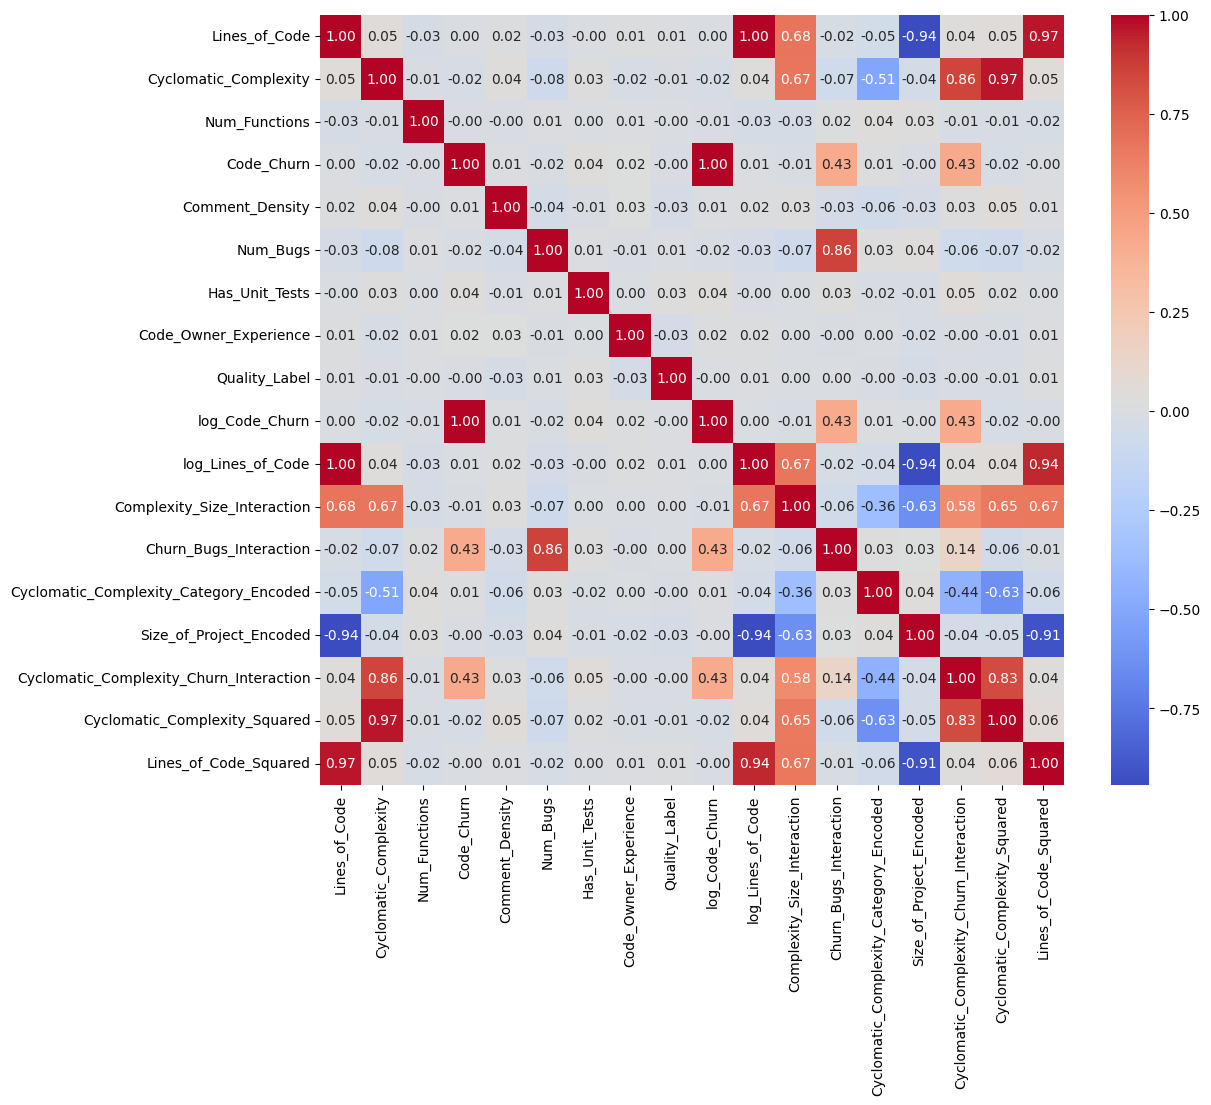

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
correlation_matrix = dataset.corr()

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()


In [ ]:
print(dataset.columns)



Index(['Lines_of_Code', 'Cyclomatic_Complexity', 'Num_Functions', 'Code_Churn',
       'Comment_Density', 'Num_Bugs', 'Has_Unit_Tests',
       'Code_Owner_Experience', 'Quality_Label', 'log_Code_Churn',
       'log_Lines_of_Code', 'Complexity_Size_Interaction',
       'Churn_Bugs_Interaction', 'Cyclomatic_Complexity_Category_Encoded',
       'Size_of_Project_Encoded', 'Cyclomatic_Complexity_Churn_Interaction',
       'Cyclomatic_Complexity_Squared', 'Lines_of_Code_Squared'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = dataset.drop(columns=['Quality_Label'])  # Features (remove the target column 'Quality_Label')
y = dataset['Quality_Label']  # Target variable (encoded as 0, 1, 2)

# Split the data into training and testing sets (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Check the shapes of the training and testing sets
print(f"Training data shape: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Testing data shape: X_test: {X_test.shape}, y_test: {y_test.shape}")



Training data shape: X_train: (1120, 17), y_train: (1120,)
Testing data shape: X_test: (480, 17), y_test: (480,)


In [ ]:
#2nd time
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train

In [ ]:
print(dataset.head(8))

   Lines_of_Code  Cyclomatic_Complexity  Num_Functions  Code_Churn  \
0       0.025273               0.625000       0.716495    0.372403   
1       0.012232               0.291667       0.510309    0.545673   
2       0.967246               0.958333       0.701031    0.509183   
3       0.693591               0.854167       0.525773    0.719710   
4       0.793368               0.708333       0.561856    0.371388   
5       0.222301               0.770833       0.592784    0.635971   
6       0.859988               0.437500       0.108247    0.331787   
7       0.442074               0.083333       0.742268    0.423856   

   Comment_Density  Num_Bugs  Has_Unit_Tests  Code_Owner_Experience  \
0         0.407729       0.2               1                  0.375   
1         0.772695       0.2               0                  0.500   
2         0.240063       0.5               0                  0.000   
3         0.968748       0.5               1                  0.250   
4         0.50

In [ ]:
##KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report




# 1. Initialize KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)

#Train the model
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# 4. Evaluate the model
print("\n KNN Classifier Results")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))



 KNN Classifier Results
Accuracy Score: 0.3167

Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.51      0.42       160
           1       0.27      0.24      0.25       150
           2       0.30      0.21      0.24       170

    accuracy                           0.32       480
   macro avg       0.31      0.32      0.30       480
weighted avg       0.31      0.32      0.30       480



In [ ]:
###NEURAL NETWORK
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
#  Initialize the Neural Network model
nn_model = MLPClassifier(hidden_layer_sizes=(50,),
                         max_iter=500,
                         random_state=42)

# Train the model
nn_model.fit(X_train, y_train)

# 3. Predict on test set
y_pred_nn = nn_model.predict(X_test)

# 4. Evaluate the model
print("\n Neural Network Classifier Results")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_nn):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn))


 Neural Network Classifier Results
Accuracy Score: 0.3521

Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.38      0.38       160
           1       0.32      0.30      0.31       150
           2       0.35      0.37      0.36       170

    accuracy                           0.35       480
   macro avg       0.35      0.35      0.35       480
weighted avg       0.35      0.35      0.35       480



/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Initialize the Random Forest Classifier model
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)

# Train the model using the training data
rf_model.fit(X_train, y_train)

# 2. Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

# 3. Evaluate the model

# Accuracy of the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest - Accuracy: {accuracy_rf:.2f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)  # For multi-class classification
print("Confusion Matrix:\n", cm_rf)

# Classification Report (Precision, Recall, F1-Score)
report_rf = classification_report(y_test, y_pred_rf)  # For multi-class classification
print("Classification Report:\n", report_rf)



Random Forest - Accuracy: 0.31
Confusion Matrix:
 [[52 46 62]
 [58 33 59]
 [59 49 62]]
Classification Report:
               precision    recall  f1-score   support

           0       0.31      0.33      0.32       160
           1       0.26      0.22      0.24       150
           2       0.34      0.36      0.35       170

    accuracy                           0.31       480
   macro avg       0.30      0.30      0.30       480
weighted avg       0.30      0.31      0.30       480



In [ ]:
##Logisctic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

#Train the model
log_reg.fit(X_train, y_train)

#Predict on test set
y_pred_logreg = log_reg.predict(X_test)

# 4. Evaluate the model
print("\nLogistic Regression Results")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_logreg):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg))


Logistic Regression Results
Accuracy Score: 0.2854

Classification Report:
               precision    recall  f1-score   support

           0       0.24      0.19      0.22       160
           1       0.25      0.19      0.22       150
           2       0.33      0.45      0.38       170

    accuracy                           0.29       480
   macro avg       0.27      0.28      0.27       480
weighted avg       0.27      0.29      0.27       480



In [ ]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate the Decision Tree model
print("Decision Tree - Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


Decision Tree - Accuracy: 0.30833333333333335
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.32      0.30      0.31       160
           1       0.26      0.25      0.25       150
           2       0.34      0.36      0.35       170

    accuracy                           0.31       480
   macro avg       0.31      0.31      0.31       480
weighted avg       0.31      0.31      0.31       480

Decision Tree Confusion Matrix:
 [[48 48 64]
 [58 38 54]
 [45 63 62]]


In [ ]:
# Cross-validation for each model
from sklearn.model_selection import cross_val_score


knn_cv_scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
dt_cv_scores = cross_val_score(dt_model, X, y, cv=5, scoring='accuracy')
log_reg_cv_scores = cross_val_score(log_reg, X, y, cv=5, scoring='accuracy')
nn_cv_scores = cross_val_score(nn_model, X, y, cv=5, scoring='accuracy')

# Print the mean cross-validation scores
print(f"KNN Cross-validation Accuracy: {knn_cv_scores.mean():.2f}")
print(f"Decision Tree Cross-validation Accuracy: {dt_cv_scores.mean():.2f}")
print(f"Logistic Regression Cross-validation Accuracy: {log_reg_cv_scores.mean():.2f}")
print(f"Neural Network Cross-validation Accuracy: {nn_cv_scores.mean():.2f}")


In [ ]:
# List models and their accuracy scores
# Assuming models are already trained
# Make predictions for each model
y_pred_knn = knn.predict(X_test)
y_pred_dt = dt_model.predict(X_test)
y_pred_log_reg = log_reg.predict(X_test)
y_pred_nn = nn_model.predict(X_test)

# Now calculate accuracies for each model
models = ['KNN', 'Decision Tree', 'Logistic Regression', 'Neural Network']
accuracies = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_log_reg),
    accuracy_score(y_test, y_pred_nn)
]

# Plotting the bar chart of accuracies
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'green', 'red', 'purple'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

# Print classification reports for all models
print("KNN Classification Report:\n", classification_report(y_test, y_pred_knn))
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_log_reg))
print("Neural Network Classification Report:\n", classification_report(y_test, y_pred_nn))

# Confusion Matrices
# KNN Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Logistic Regression Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Neural Network Confusion Matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Neural Network Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


Precision, Recall Comparison of Each Model (for Classification)

In [ ]:
# Extract precision and recall from classification reports
precision = [
    classification_report(y_test, y_pred_knn, output_dict=True)['accuracy'],
    classification_report(y_test, y_pred_dt, output_dict=True)['accuracy'],
    classification_report(y_test, y_pred_log_reg, output_dict=True)['accuracy'],
    classification_report(y_test, y_pred_nn, output_dict=True)['accuracy']
]

recall = [
    classification_report(y_test, y_pred_knn, output_dict=True)['accuracy'],
    classification_report(y_test, y_pred_dt, output_dict=True)['accuracy'],
    classification_report(y_test, y_pred_log_reg, output_dict=True)['accuracy'],
    classification_report(y_test, y_pred_nn, output_dict=True)['accuracy']
]

# Bar chart visualization
labels = ['KNN', 'Decision Tree', 'Logistic Regression', 'Neural Network']

plt.figure(figsize=(10, 6))
barWidth = 0.3
r1 = range(len(labels))
r2 = [x + barWidth for x in r1]

# Plot the bars
plt.bar(r1, precision, color='blue', width=barWidth, label='Precision')
plt.bar(r2, recall, color='green', width=barWidth, label='Recall')

# Add labels and title
plt.xlabel('Models', fontweight='bold')
plt.ylabel('Scores', fontweight='bold')
plt.xticks([r + barWidth / 2 for r in range(len(labels))], labels)
plt.title('Precision and Recall Comparison for Each Model')
plt.legend()

plt.show()


AUC Score, ROC Curve (for Classification)


In [ ]:
from sklearn.metrics import roc_curve, auc

# Function to plot ROC curve and AUC score
def plot_roc_curve(y_test, y_pred_prob, model_name):
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob[:, 1], pos_label=1)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

# Get predicted probabilities for each model
y_pred_prob_knn = knn.predict_proba(X_test)
y_pred_prob_dt = dt_model.predict_proba(X_test)
y_pred_prob_log_reg = log_reg.predict_proba(X_test)
y_pred_prob_nn = nn_model.predict_proba(X_test)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plot_roc_curve(y_test, y_pred_prob_knn, 'KNN')
plot_roc_curve(y_test, y_pred_prob_dt, 'Decision Tree')
plot_roc_curve(y_test, y_pred_prob_log_reg, 'Logistic Regression')
plot_roc_curve(y_test, y_pred_prob_nn, 'Neural Network')

plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line for random guess
plt.title('ROC Curve Comparison for Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


In [ ]:
#2nd time
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate the model
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
